# Leave-one-out $\lambda_m$ and $\rho_m$

Perfect-model skill from each member against the mean of the others. For every grid cell
and every member $n$, with $s_{-n}$ the ensemble mean over the other $N-1$ members:

$$I_n = I\big(f_n;s_{-n}\big),\quad
\lambda_m = \frac1N\sum_n \sqrt{1-2^{-2I_n}},\qquad
\rho_m = \frac1N\sum_n \mathrm{corr}\big(f_n,s_{-n}\big)$$

$\lambda$ is formed per member and *then* averaged; averaging $I_n$ first and transforming
once gives a different, larger number. MI comes from `infomeasure`'s KSG estimator via
`scripts/infomeasure_rpc.py` (bits, `noise_level=0`, max norm, rank/copula transform,
$k=5$).

Both are computed on the data as it comes and on month-of-year anomalies, since the
preprocessing removes a linear trend but no seasonal cycle.

**Handles**

| name | shape | meaning |
|---|---|---|
| `I_N[t]` | `(49, 64, 128)` | $I_n$ in bits, per member |
| `LAM_N[t]` | `(49, 64, 128)` | $\lambda_n$, per member |
| `LAM_M[t]` | `(64, 128)` | $\lambda_m$ |
| `R_N[t]` | `(49, 64, 128)` | $r_n$, per member |
| `RHO_M[t]` | `(64, 128)` | $\rho_m$ |
| `rho_m_var` | `(64, 128)` | published variance-based $\rho_m$, for reference |

`t` is one of `TREATMENTS`; `panel(ax, field, cmap, norm, title)` draws a map.

In [96]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()

# Repair the two defective edge longitude columns. In the raw ensemble file members
# 10-19 have no data at all at lon index 0 (0.00E) and members 20-39 none at index 127
# (357.19E) -- whole model groups missing one edge column, from regridding onto the
# common grid without periodic longitude handling. Zero-filled they read as a stripe
# down the middle of every rolled map. Fill each from its nearest longitude neighbour;
# timesteps missing for other reasons (calendar 1971 for members 10-19) stay NaN.
_psl = f.psl.to_numpy()
for _bad, _good in ((0, 1), (127, 126)):
    _col = _psl[:, :, :, _bad]
    _psl[:, :, :, _bad] = np.where(np.isnan(_col), _psl[:, :, :, _good], _col)
f["psl"] = (f.psl.dims, _psl)
s = f.mean("n")

rho_m_var = R.var_RPC(f, s, obs)[1].to_numpy()

PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180        # grid is 0..357E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=12)
    return h

## Leave-one-out means

`loo_mean(n)` returns $s_{-n}$ as a `(T, lat, lon)` field, built from the total nan-aware
sum and count rather than 49 separate `nanmean` calls -- exact, and avoids a second copy
of the ensemble.

In [97]:
F = f.psl.to_numpy()                       # (N, T, lat, lon), NaNs intact
N, T = F.shape[:2]
_valid = ~np.isnan(F)
_sum = np.nansum(F, axis=0)
_count = _valid.sum(axis=0)
month = np.arange(T) % 12


def loo_mean(n):
    """Ensemble mean excluding member n: nan-aware, then zero-filled."""
    num = _sum - np.where(_valid[n], F[n], 0.0)
    den = _count - _valid[n]
    return np.nan_to_num(np.where(den > 0, num / np.maximum(den, 1), np.nan), nan=0.0)


def deseason(a):
    """Subtract the month-of-year climatology along the time axis."""
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def pair(n, treatment):
    """(f_n, s_-n) ready for an estimator, both (T, lat, lon)."""
    f_n, s_n = np.nan_to_num(F[n], nan=0.0), loo_mean(n)
    return (deseason(f_n), deseason(s_n)) if treatment == "deseasonalised" else (f_n, s_n)


with warnings.catch_warnings():                            # loo_mean is exact
    warnings.simplefilter("ignore", RuntimeWarning)
    for _n in (0, 12, 48):
        _d = np.nan_to_num(np.nanmean(np.delete(F[:, :, 32, 21], _n, axis=0), axis=0), nan=0.0)
        assert np.allclose(loo_mean(_n)[:, 32, 21], _d)

## $\lambda_m$

One KSG call per member per grid cell, $49\times64\times128$ of them. A cold run of both
treatments takes about eight minutes, so it is cached.

In [98]:
CACHE = "../data/granger_lin_cache.npz"
TREATMENTS = ["as-is", "deseasonalised"]
K = 5


def lam(I):
    """sqrt(1 - 2^-2I), argument of the sqrt clamped at 0."""
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


def loo_mi(treatment):
    """I(f_n ; s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_bits(f_n[:, la, lo], s_n[:, la, lo], "ksg", param=K)
    return out


if os.path.exists(CACHE):
    _z = np.load(CACHE)
    I_N = {t: _z[t] for t in TREATMENTS}
else:
    I_N = {t: loo_mi(t) for t in TREATMENTS}
    np.savez_compressed(CACHE, **I_N)

LAM_N = {t: lam(I_N[t]) for t in TREATMENTS}              # (N, lat, lon)
LAM_M = {t: LAM_N[t].mean(axis=0) for t in TREATMENTS}    # (lat, lon)

## $\rho_m$

Same construction, Pearson correlation instead of MI. Vectorised over the grid, so this is
seconds and needs no cache.

In [99]:
def loo_pearson(treatment):
    """corr(f_n, s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        a = f_n - f_n.mean(axis=0, keepdims=True)
        b = s_n - s_n.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


R_N = {t: loo_pearson(t) for t in TREATMENTS}             # (N, lat, lon)
RHO_M = {t: np.nanmean(R_N[t], axis=0) for t in TREATMENTS}   # (lat, lon)

_ok = np.isfinite(rho_m_var)
print("%-15s %8s %8s %8s" % ("treatment", "lam_m", "rho_m", "corr"))
for t in TREATMENTS:
    m = np.isfinite(LAM_M[t]) & np.isfinite(RHO_M[t])
    print("%-15s %8.4f %+8.4f %+8.3f"
          % (t, LAM_M[t].mean(), np.nanmean(RHO_M[t]),
             np.corrcoef(LAM_M[t][m], RHO_M[t][m])[0, 1]))
print("\nrho_m as-is vs published variance-based rho_m: corr %+.3f, means %.4f / %.4f"
      % (np.corrcoef(RHO_M["as-is"][_ok], rho_m_var[_ok])[0, 1],
         np.nanmean(RHO_M["as-is"]), rho_m_var[_ok].mean()))

treatment          lam_m    rho_m     corr
as-is             0.6386  +0.5753   +0.992
deseasonalised    0.2099  +0.0449   +0.495

rho_m as-is vs published variance-based rho_m: corr +0.997, means 0.5753 / 0.6083


## Maps

One figure per treatment: $\lambda_m$ left, $\rho_m$ right, sharing a colour scale that
spans both panels.

The vertical line down the centre of every map is longitude 0 (the prime meridian, not the date line -- that sits at the map edges). Original longitude columns 0 (0.00E) and 127 (357.19E) are 20.7% and 42.9% NaN in the raw ensemble file: members 10-19 are missing column 0 entirely and members 20-39 column 127 entirely, from regridding onto the common grid without periodic longitude handling. Rolling to -180..180 puts those two columns adjacent at plotted columns 63 and 64, i.e. dead centre. The observations are 0% NaN throughout.

['as-is', 'deseasonalised']
0
1


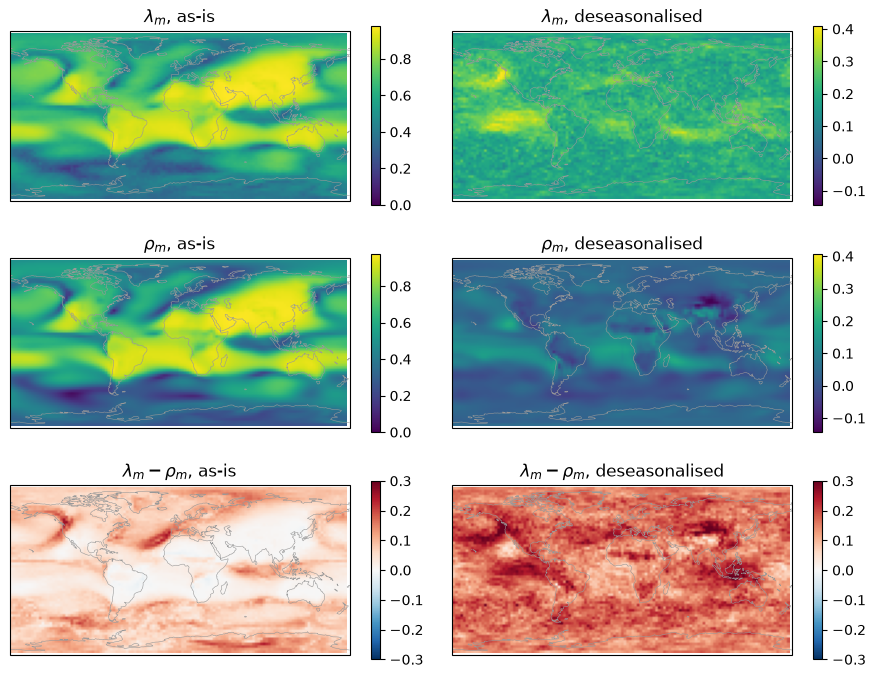

In [100]:
print(TREATMENTS)

fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    print(i)
    a, b = LAM_M[t], RHO_M[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_m$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_m$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_m - \\rho_m$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

## $\lambda_m$ against $\rho_m$, and the spread across members

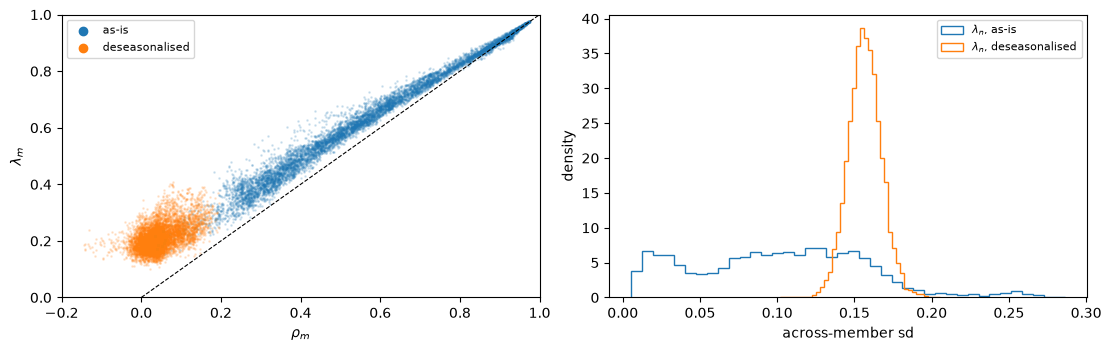

treatment         lam_n sd     r_n sd        I_n<0
as-is                0.101      0.104         2.0%
deseasonalised       0.157      0.110        27.9%


In [101]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_M[t].ravel(), LAM_M[t].ravel(), s=1, alpha=0.15, color=c, label=t)
axs[0].plot([-0.2, 1], [-0.2, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho_m$")
axs[0].set_ylabel("$\\lambda_m$")
axs[0].set_xlim(-0.2, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_N[t].std(axis=0).ravel(), bins=40, histtype="step",
                density=True, color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-15s %10s %10s %12s" % ("treatment", "lam_n sd", "r_n sd", "I_n<0"))
for t in TREATMENTS:
    print("%-15s %10.3f %10.3f %11.1f%%"
          % (t, LAM_N[t].std(axis=0).mean(), np.nanstd(R_N[t], axis=0).mean(),
             100 * np.mean(I_N[t] < 0)))

## $\lambda_o$ and $\rho_o$

Same construction with the observations $g$ in place of $s_{-n}$, so there is nothing to
leave out -- each member is scored against the same external target:

$$\lambda_o = \frac1N\sum_n \sqrt{1-2^{-2\,I(f_n;\,g)}},\qquad
\rho_o = \frac1N\sum_n \mathrm{corr}\big(f_n,g\big)$$

`mi_grid` and `pearson_grid` take whichever pairing function they are given, so the model
and observation sides cannot drift apart in their NaN or deseasonalising handling.

Adds `I_O[t]`, `LAM_O_N[t]`, `R_O_N[t]` at `(49, 64, 128)` and `LAM_O[t]`, `RHO_O[t]` at
`(64, 128)`, plus `rho_o_var` = published $\mathrm{corr}(s,g)$ for reference.

In [102]:
OBS_CACHE = "../data/granger_lin_obs_cache.npz"
G = np.nan_to_num(obs.psl.to_numpy(), nan=0.0)          # (T, lat, lon)
G_ds = deseason(G)
rho_o_var = R.var_RPC(f, s, obs)[0].to_numpy()


def pair_obs(n, treatment):
    """(f_n, g) ready for an estimator, both (T, lat, lon)."""
    f_n = np.nan_to_num(F[n], nan=0.0)
    if treatment == "deseasonalised":
        return deseason(f_n), G_ds
    return f_n, G


def mi_grid(pairfn, treatment):
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
    return out


def pearson_grid(pairfn, treatment):
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        x, y = pairfn(n, treatment)
        a = x - x.mean(axis=0, keepdims=True)
        b = y - y.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


if os.path.exists(OBS_CACHE):
    _z = np.load(OBS_CACHE)
    I_O = {t: _z[t] for t in TREATMENTS}
else:
    I_O = {t: mi_grid(pair_obs, t) for t in TREATMENTS}
    np.savez_compressed(OBS_CACHE, **I_O)

LAM_O_N = {t: lam(I_O[t]) for t in TREATMENTS}                 # (N, lat, lon)
LAM_O = {t: LAM_O_N[t].mean(axis=0) for t in TREATMENTS}       # (lat, lon)
R_O_N = {t: pearson_grid(pair_obs, t) for t in TREATMENTS}     # (N, lat, lon)
RHO_O = {t: np.nanmean(R_O_N[t], axis=0) for t in TREATMENTS}  # (lat, lon)

_ok_o = np.isfinite(rho_o_var)
print("%-15s %8s %8s %8s" % ("treatment", "lam_o", "rho_o", "corr"))
for t in TREATMENTS:
    m = np.isfinite(LAM_O[t]) & np.isfinite(RHO_O[t])
    print("%-15s %8.4f %+8.4f %+8.3f"
          % (t, LAM_O[t].mean(), np.nanmean(RHO_O[t]),
             np.corrcoef(LAM_O[t][m], RHO_O[t][m])[0, 1]))
print("\npublished corr(s, g): mean %.4f, corr with rho_o as-is %+.3f"
      % (rho_o_var[_ok_o].mean(),
         np.corrcoef(RHO_O["as-is"][_ok_o], rho_o_var[_ok_o])[0, 1]))

treatment          lam_o    rho_o     corr
as-is             0.5094  +0.4241   +0.989
deseasonalised    0.1997  +0.0034   +0.001

published corr(s, g): mean 0.6252, corr with rho_o as-is +0.940


## Maps

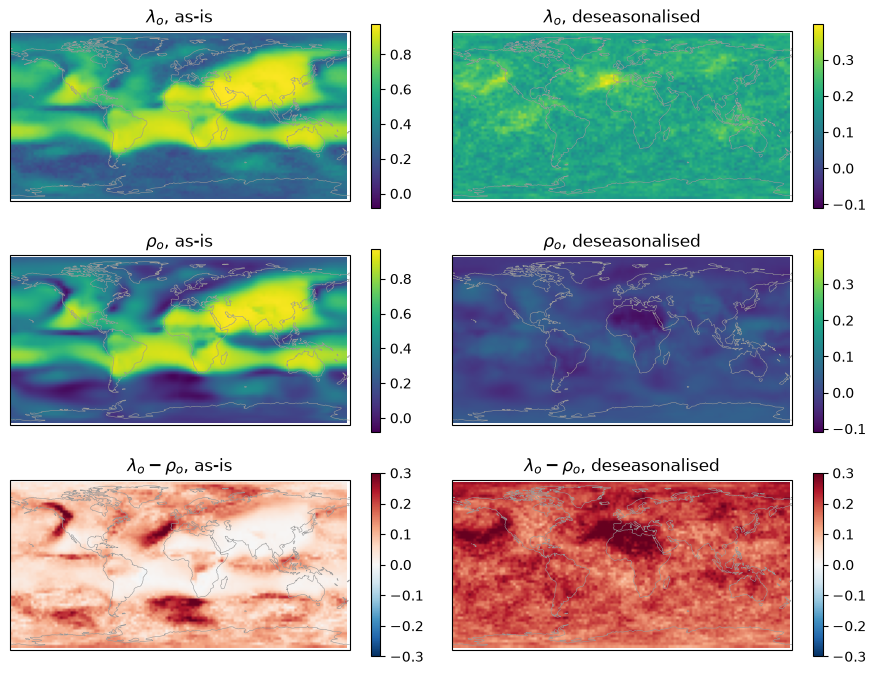

In [103]:
fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    a, b = LAM_O[t], RHO_O[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_o$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_o$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_o - \\rho_o$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

## $\lambda_o$ against $\rho_o$, and the spread across members

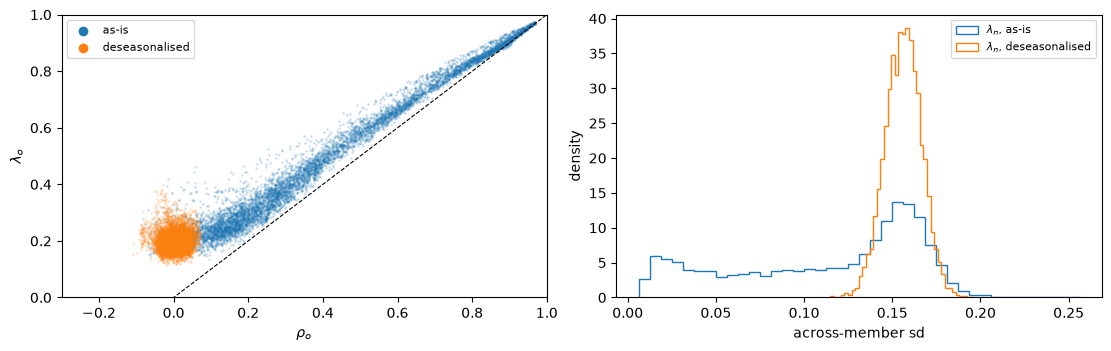

treatment         lam_n sd     r_n sd        I_n<0
as-is                0.113      0.096         7.7%
deseasonalised       0.156      0.110        29.6%


In [104]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_O[t].ravel(), LAM_O[t].ravel(), s=1, alpha=0.15, color=c, label=t)
axs[0].plot([-0.3, 1], [-0.3, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho_o$")
axs[0].set_ylabel("$\\lambda_o$")
axs[0].set_xlim(-0.3, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_O_N[t].std(axis=0).ravel(), bins=40, histtype="step",
                density=True, color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-15s %10s %10s %12s" % ("treatment", "lam_n sd", "r_n sd", "I_n<0"))
for t in TREATMENTS:
    print("%-15s %10.3f %10.3f %11.1f%%"
          % (t, LAM_O_N[t].std(axis=0).mean(), np.nanstd(R_O_N[t], axis=0).mean(),
             100 * np.mean(I_O[t] < 0)))

## $\lambda_o$ and $\rho_o$ the other way round: average the ensemble first

Above, each member was scored against $g$ and the skills were averaged. Here the ensemble
is collapsed to its mean $s$ first, and only that one series is compared with $g$:

$$\rho_o^{\,s} = \mathrm{corr}(s, g), \qquad
\lambda_o^{\,s} = \sqrt{1 - 2^{-2\,I(s;\,g)}}$$

One estimate per grid cell instead of 49, so this is seconds and needs no cache. $s$ is the
published skipna ensemble mean.

Adds `LAM_O_S[t]` and `RHO_O_S[t]` at `(64, 128)`. Note $\rho_o^{\,s}$ is left unclamped;
the published `rho_o_var` is the same field with negatives set to zero.

In [105]:
S = np.nan_to_num(s.psl.to_numpy(), nan=0.0)            # published skipna ensemble mean
S_ds = deseason(S)


def sig_pair(treatment):
    return (S_ds, G_ds) if treatment == "deseasonalised" else (S, G)


RHO_O_S, LAM_O_S = {}, {}
for t in TREATMENTS:
    x, y = sig_pair(t)
    a = x - x.mean(axis=0, keepdims=True)
    b = y - y.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        RHO_O_S[t] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    LAM_O_S[t] = lam(np.array([[R.mi_bits(x[:, la, lo], y[:, la, lo], "ksg", param=K)
                                for lo in range(S.shape[2])]
                               for la in range(S.shape[1])]))

print("%-15s %9s %9s %11s %11s" % ("treatment", "lam_o^s", "rho_o^s",
                                   "lam_o (mem)", "rho_o (mem)"))
for t in TREATMENTS:
    print("%-15s %9.4f %+9.4f %11.4f %+11.4f"
          % (t, LAM_O_S[t].mean(), np.nanmean(RHO_O_S[t]),
             LAM_O[t].mean(), np.nanmean(RHO_O[t])))
print("\nrho_o^s as-is is the published rho_o up to its clamp at zero: %s (%.1f%% of "
      "cells are negative)"
      % (np.allclose(np.maximum(RHO_O_S["as-is"], 0.0), rho_o_var, equal_nan=True),
         100 * np.mean(RHO_O_S["as-is"] < 0)))

treatment         lam_o^s   rho_o^s lam_o (mem) rho_o (mem)
as-is              0.7002   +0.6237      0.5094     +0.4241
deseasonalised     0.2061   +0.0310      0.1997     +0.0034

rho_o^s as-is is the published rho_o up to its clamp at zero: True (1.7% of cells are negative)


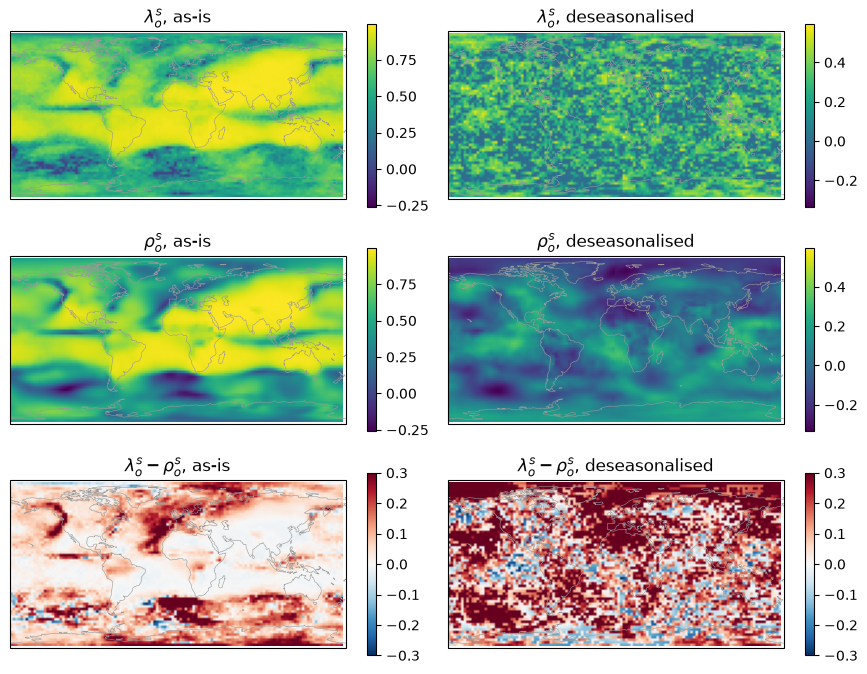

In [106]:
fig, axs = plt.subplots(3, 2, figsize=(9, 7),
                        subplot_kw={"projection": PROJ})
for (i, t) in enumerate(TREATMENTS):
    a, b = LAM_O_S[t], RHO_O_S[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    nrm_compare = Normalize(-0.3, 0.3)
    h0 = panel(axs[0, i], a, "viridis", nrm, "$\\lambda_o^s$, %s" % t)
    h1 = panel(axs[1, i], b, "viridis", nrm, "$\\rho_o^s$, %s" % t)
    h2 = panel(axs[2, i], a-b, "RdBu_r", nrm_compare, "$\\lambda_o^s - \\rho_o^s$, %s" % t)
    fig.colorbar(h0, ax=axs[0, i], shrink=0.85, label="")
    fig.colorbar(h1, ax=axs[1, i], shrink=0.85, label="")
    fig.colorbar(h2, ax=axs[2, i], shrink=0.85, label="")
plt.tight_layout()
plt.show()

# Compare Ratio of Predictable Components

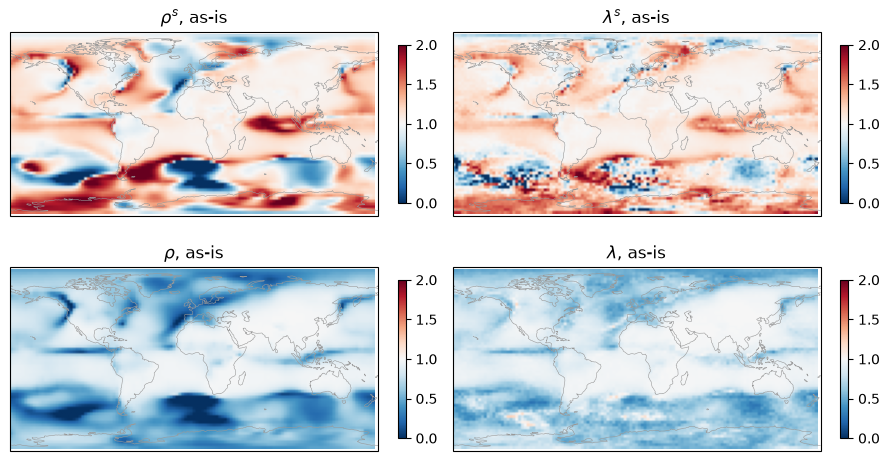

In [107]:
t='as-is'
fig, axs = plt.subplots(2, 2, figsize=(9, 5),
                        subplot_kw={"projection": PROJ})

lam_os, rho_os = LAM_O_S[t], RHO_O_S[t]
lam_o, rho_o = LAM_O[t], RHO_O[t]
lam_m, rho_m = LAM_M[t], RHO_M[t]

lam_s = lam_os / lam_m
rho_s = rho_os / rho_m 
lam = lam_o / lam_m
rho = rho_o / rho_m 

nrm = Normalize(0.0, 2.0)
nrm_compare = Normalize(-0.3, 0.3)
h0 = panel(axs[0,0], rho_s, "RdBu_r", nrm, "$\\rho^s$, %s" % t)
h1 = panel(axs[0,1], lam_s, "RdBu_r", nrm, "$\\lambda^s$, %s" % t)
h2 = panel(axs[1,0], rho, "RdBu_r", nrm, "$\\rho$, %s" % t)
h3 = panel(axs[1,1], lam, "RdBu_r", nrm, "$\\lambda$, %s" % t)
fig.colorbar(h0, ax=axs[0, 0], fraction=0.02)
fig.colorbar(h1, ax=axs[0, 1], fraction=0.02)
fig.colorbar(h2, ax=axs[1, 0], fraction=0.02)
fig.colorbar(h3, ax=axs[1, 1], fraction=0.02)
plt.tight_layout()

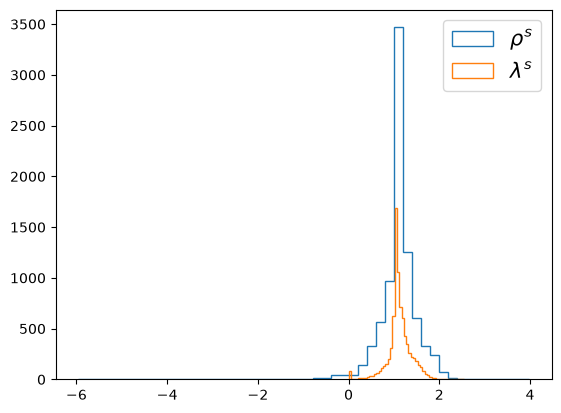

In [108]:
plt.hist(rho_s.flatten(), histtype='step', bins=50, label='$\\rho^s$')
plt.hist(lam_s.flatten(), histtype='step', bins=50, label='$\\lambda^s$')
plt.legend(fontsize=15)

Text(0.5, 0, '$\\rho^s$')

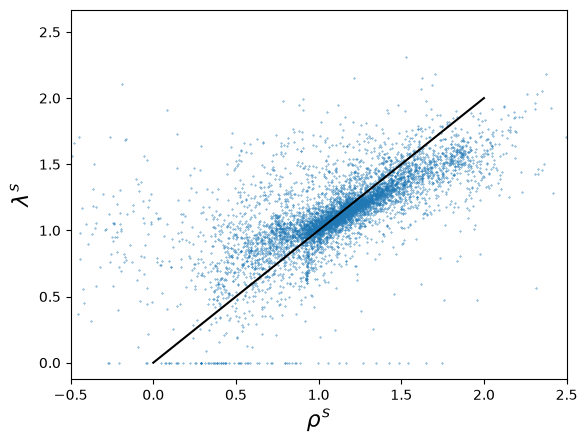

In [109]:
plt.scatter(rho_s, lam_s, 0.1)
x=np.linspace(0,2,20)
plt.plot(x, x, 'k-')
plt.xlim(-0.5, 2.5)
plt.ylabel('$\\lambda^s$', fontsize=16)
plt.xlabel('$\\rho^s$', fontsize=16)

Text(0.5, 0, '$\\rho$')

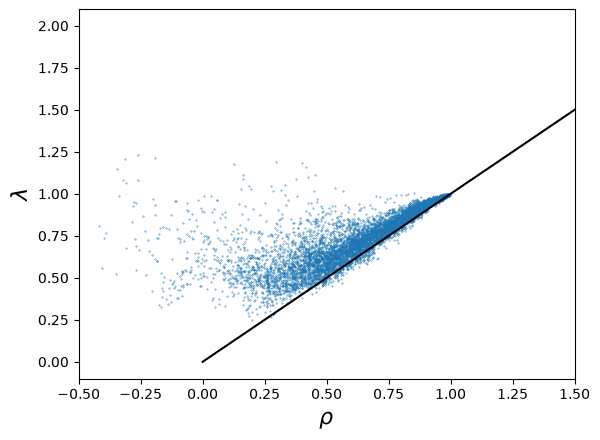

In [110]:
plt.scatter(rho, lam, 0.1)
x=np.linspace(0,2,20)
plt.plot(x, x, 'k-')
plt.xlim(-0.5, 1.5)
plt.ylabel('$\\lambda$', fontsize=16)
plt.xlabel('$\\rho$', fontsize=16)

In [111]:
print(np.max(lam_s) - np.min(lam_s))
print(np.max(rho_s) - np.min(rho_s))

2.5398021807999265
9.940991987760674


## $I(f_n; F_{-n})$ by the conditional chain rule

$s_{-n}$ is a linear average, so it cannot carry non-linear structure in the leave-one-out
ensemble. Summarising $F_{-n}$ by four moments and estimating in one go pays a steep
dimension penalty at $T=120$; the chain rule gets the same quantity without ever leaving
low dimension:

$$I(f_n;\,\mu,\sigma,\mathrm{sk},\mathrm{ku}) = I(f_n;\mu)
+ I(\sigma;f_n\mid\mu) + I(\mathrm{sk};f_n\mid\mu,\sigma)
+ I(\mathrm{ku};f_n\mid\mu,\sigma,\mathrm{sk})$$

Each term comes from `im.cmi(extra, f_n, cond=already_included)`, so the conditioning set
never exceeds three variables. Each carries its own bias, so each gets its own null:
permute the extra feature in time with $f_n$ and the conditioning set left aligned.

term                       value      null    excess
mean                     +0.4623   +0.0340   +0.4283
std | mean               +0.0570   +0.0286   +0.0284
skew | mean,std          +0.0428   +0.0283   +0.0145
kurt | mean,std,skew     +0.0216   +0.0286   -0.0071
chain-rule total         +0.5836             +0.4641

members   chain total    direct 4-D
      4        0.4487        0.2584
      6        0.4953        0.2799
      8        0.4901        0.2877
     12        0.5183        0.3082
     16        0.5549        0.3229
     24        0.5659        0.3284
     32        0.5728        0.3316
     40        0.5733        0.3361
     48        0.5836        0.3375


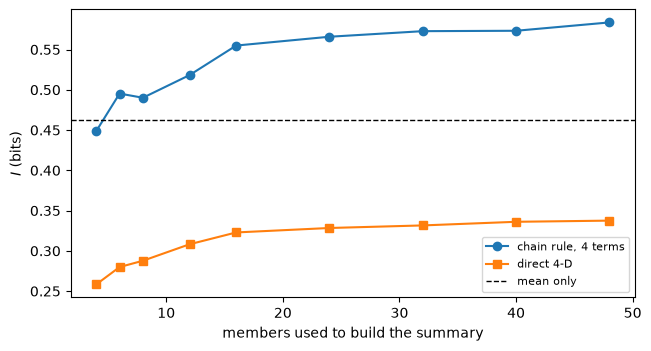

In [112]:
import infomeasure as im      # not imported in the cell above


def to_ranks(a):
    """Rank/copula transform, column-wise for 2-D input."""
    a = np.asarray(a, float)
    return R.copula(a) if a.ndim == 1 else np.column_stack(
        [R.copula(a[:, j]) for j in range(a.shape[1])])


def conditional_mi_bits(extra, target, given):
    """I(extra; target | given) in bits, same conventions as R.mi_bits."""
    return float(im.cmi(to_ranks(extra), to_ranks(target), cond=to_ranks(given),
                        approach="ksg", k=K, base=2, noise_level=0))


def moment_summary(members):
    """(n_members, T) -> (T, 4) of mean, sd, skew, kurt."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = np.nanmean(members, axis=0)
        d = members - mean
        var = np.nanmean(d ** 2, axis=0)
        out = np.column_stack([mean, np.sqrt(var),
                               np.nanmean(d ** 3, axis=0) / var ** 1.5,
                               np.nanmean(d ** 4, axis=0) / var ** 2])
    return np.nan_to_num(out, nan=0.0)


def chain_steps(summary):
    """The four (name, extra, given) steps; `given` is None for the first."""
    mean, sd, skew, kurt = summary.T
    return [("mean", mean, None),
            ("std | mean", sd, mean),
            ("skew | mean,std", skew, np.column_stack([mean, sd])),
            ("kurt | mean,std,skew", kurt, np.column_stack([mean, sd, skew]))]


def step_value(extra, target, given):
    return (R.mi_bits(extra, target, "ksg", param=K) if given is None
            else conditional_mi_bits(extra, target, given))


HELD_OUT_MEMBERS = [0, 12, 25, 37, 48]
SAMPLE_POINTS = [(la, lo) for la in range(6, 60, 13) for lo in range(0, 128, 32)]
N_PERMUTATIONS = 20
MEMBER_COUNTS = [4, 6, 8, 12, 16, 24, 32, 40, 48]
MEMBER_ORDER = np.random.default_rng(0).permutation(N)   # nested, model-mixed subsets

term_value, term_null = {}, {}
chain_total_by_count, direct_4d_by_count = {}, {}

for lat_idx, lon_idx in SAMPLE_POINTS:
    members_here = np.nan_to_num(F[:, :, lat_idx, lon_idx], nan=0.0)
    for held in HELD_OUT_MEMBERS:
        target = members_here[held]
        rng = np.random.default_rng(lat_idx * 1000 + lon_idx + held)

        for name, extra, given in chain_steps(
                moment_summary(np.delete(members_here, held, axis=0))):
            term_value.setdefault(name, []).append(step_value(extra, target, given))
            term_null.setdefault(name, []).append(np.mean(
                [step_value(rng.permutation(extra), target, given)
                 for _ in range(N_PERMUTATIONS)]))

        order = [m for m in MEMBER_ORDER if m != held]
        for count in MEMBER_COUNTS:
            summary = moment_summary(members_here[order[:count]])
            chain_total_by_count.setdefault(count, []).append(
                sum(step_value(e, target, g) for _, e, g in chain_steps(summary)))
            direct_4d_by_count.setdefault(count, []).append(
                R.mi_bits(summary, target, "ksg", param=K))

print("%-22s %9s %9s %9s" % ("term", "value", "null", "excess"))
total = total_excess = 0.0
for name in term_value:
    value, null = np.mean(term_value[name]), np.mean(term_null[name])
    total, total_excess = total + value, total_excess + value - null
    print("%-22s %+9.4f %+9.4f %+9.4f" % (name, value, null, value - null))
print("%-22s %+9.4f %9s %+9.4f" % ("chain-rule total", total, "", total_excess))

print("\n%7s %13s %13s" % ("members", "chain total", "direct 4-D"))
for count in MEMBER_COUNTS:
    print("%7d %13.4f %13.4f"
          % (count, np.mean(chain_total_by_count[count]),
             np.mean(direct_4d_by_count[count])))

fig, ax = plt.subplots(figsize=(6.4, 3.4), layout="constrained")
ax.plot(MEMBER_COUNTS, [np.mean(chain_total_by_count[c]) for c in MEMBER_COUNTS],
        "o-", label="chain rule, 4 terms")
ax.plot(MEMBER_COUNTS, [np.mean(direct_4d_by_count[c]) for c in MEMBER_COUNTS],
        "s-", label="direct 4-D")
ax.axhline(np.mean(term_value["mean"]), ls="--", color="k", lw=1, label="mean only")
ax.set_xlabel("members used to build the summary")
ax.set_ylabel("$I$ (bits)")
ax.legend(fontsize=8)
plt.show()

## $\lambda_m$ from the chain rule, mapped

The same chain-rule total, now over the whole grid and every member, turned into $\lambda$
per member and averaged as before. Compared against the existing $\lambda_m$, which uses
the leave-one-out mean alone. As-is treatment; a cold run is about 19 minutes, so it is
cached.

                           mean      min      max
lam_m chain rule         0.7168   0.3795   0.9831
lam_m mean only          0.6386   0.1537   0.9779
difference               0.0782   0.0027   0.2878

spatial correlation +0.989;  chain rule higher at 100.0% of cells


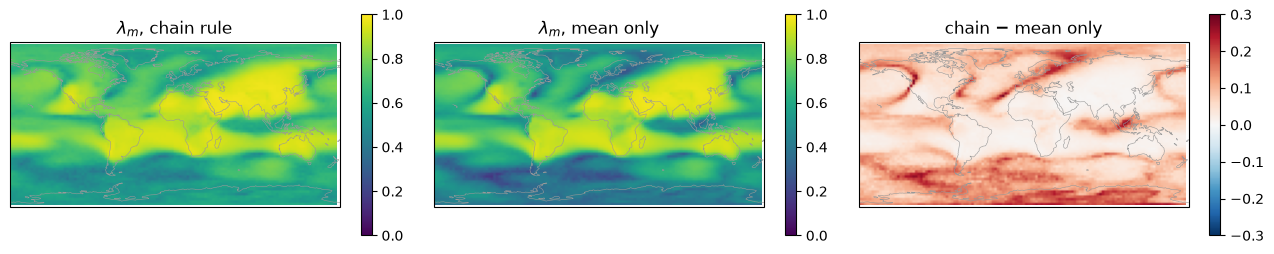

In [113]:
def lam_from_mi(mi_bits):
    """sqrt(1 - 2^-2I), sqrt argument clamped at 0. Local, because `lam` is
    rebound to an array by a cell above."""
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * mi_bits)))


CHAIN_CACHE = "../data/granger_lin_chain_cache.npz"

if os.path.exists(CHAIN_CACHE):
    chain_mi_per_member = np.load(CHAIN_CACHE)["chain_mi"]
else:
    chain_mi_per_member = np.empty((N,) + F.shape[2:])      # (N, lat, lon), bits
    for lat_idx in range(F.shape[2]):
        for lon_idx in range(F.shape[3]):
            members_here = np.nan_to_num(F[:, :, lat_idx, lon_idx], nan=0.0)
            for held in range(N):
                summary = moment_summary(np.delete(members_here, held, axis=0))
                chain_mi_per_member[held, lat_idx, lon_idx] = sum(
                    step_value(extra, members_here[held], given)
                    for _, extra, given in chain_steps(summary))
    np.savez_compressed(CHAIN_CACHE, chain_mi=chain_mi_per_member)

lam_m_chain = lam_from_mi(chain_mi_per_member).mean(axis=0)   # (lat, lon)
lam_m_mean_only = LAM_M["as-is"]

print("%-22s %8s %8s %8s" % ("", "mean", "min", "max"))
for name, field in (("lam_m chain rule", lam_m_chain),
                    ("lam_m mean only", lam_m_mean_only),
                    ("difference", lam_m_chain - lam_m_mean_only)):
    print("%-22s %8.4f %8.4f %8.4f" % (name, field.mean(), field.min(), field.max()))
print("\nspatial correlation %+.3f;  chain rule higher at %.1f%% of cells"
      % (np.corrcoef(lam_m_chain.ravel(), lam_m_mean_only.ravel())[0, 1],
         100 * np.mean(lam_m_chain > lam_m_mean_only)))

fig, axs = plt.subplots(1, 3, figsize=(13, 2.9), subplot_kw={"projection": PROJ})
shared = Normalize(0, 1)
for ax, (field, title, cmap, nrm) in zip(axs, [
        (lam_m_chain, "$\\lambda_m$, chain rule", "viridis", shared),
        (lam_m_mean_only, "$\\lambda_m$, mean only", "viridis", shared),
        (lam_m_chain - lam_m_mean_only, "chain $-$ mean only", "RdBu_r",
         Normalize(-0.3, 0.3))]):
    h = panel(ax, field, cmap, nrm, title)
    fig.colorbar(h, ax=ax, shrink=0.85, label="")
plt.tight_layout()
plt.show()

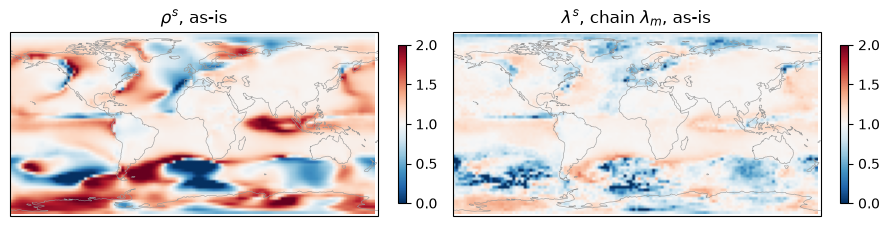

                                 mean     % > 1
rho^s                          1.0900     77.0%
lam^s, mean-only denom         1.1144     83.9%
lam^s, chain denom             0.9647     66.3%


In [114]:
treatment = "as-is"
rho_ratio = RHO_O_S[treatment] / RHO_M[treatment]              # unchanged
lam_ratio_chain = LAM_O_S[treatment] / lam_m_chain             # chain-rule denominator
lam_ratio_mean_only = LAM_O_S[treatment] / LAM_M[treatment]    # for the numbers below

fig, axs = plt.subplots(1, 2, figsize=(9, 2.6), subplot_kw={"projection": PROJ})
nrm_ratio = Normalize(0.0, 2.0)
h0 = panel(axs[0], rho_ratio, "RdBu_r", nrm_ratio, "$\\rho^s$, %s" % treatment)
h1 = panel(axs[1], lam_ratio_chain, "RdBu_r", nrm_ratio,
           "$\\lambda^s$, chain $\\lambda_m$, %s" % treatment)
fig.colorbar(h0, ax=axs[0], fraction=0.02)
fig.colorbar(h1, ax=axs[1], fraction=0.02)
plt.tight_layout()
plt.show()

print("%-28s %8s %9s" % ("", "mean", "% > 1"))
for name, field in (("rho^s", rho_ratio),
                    ("lam^s, mean-only denom", lam_ratio_mean_only),
                    ("lam^s, chain denom", lam_ratio_chain)):
    print("%-28s %8.4f %8.1f%%"
          % (name, np.nanmean(field),
             100 * R.area_weighted_fraction(field, lats, threshold=1.0)))

Text(0, 0.5, 'Density')

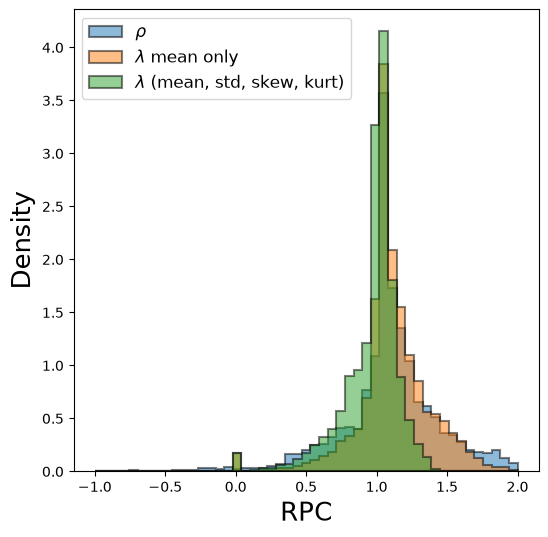

In [151]:
BINS = np.linspace(-1, 2, 50) 
BIN_LW = 1.5
LABEL_FONTSIZE = 19
fig, axs = plt.subplots(1, 1, figsize=(6, 6))

axs.hist(rho_ratio.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\rho$', bins=BINS)
axs.hist(lam_ratio_mean_only.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\lambda$ mean only', bins=BINS)
axs.hist(lam_ratio_chain.flatten(), density=True, histtype='stepfilled', alpha=0.5, lw=BIN_LW, ec='k', label='$\\lambda$ (mean, std, skew, kurt)', bins=BINS)

axs.legend(fontsize=12, loc='upper left')
axs.set_xlabel('RPC', fontsize=LABEL_FONTSIZE)
axs.set_ylabel('Density', fontsize=LABEL_FONTSIZE)

## Do the quantiles add anything? $q_{10}, q_{50}, q_{90}$ in the chain

Extends the summary of $F_{-n}$ from four moments to seven features by appending the
across-member deciles, and keeps going with the same chain rule:

$$I(f_n;\,\mu,\sigma,\mathrm{sk},\mathrm{ku},q_{10},q_{50},q_{90})
= I(f_n;\mu) + I(\sigma;f_n\mid\mu) + \cdots
+ I(q_{90};f_n\mid\mu,\sigma,\mathrm{sk},\mathrm{ku},q_{10},q_{50})$$

Every term is still a 1-D `extra` against a 1-D target, so no term pays the dimension
penalty of a 7-D estimate. The conditioning set grows to six columns, which `im.cmi`
accepts. Conditional bias grows with the size of the conditioning set, so each term keeps
its own permutation null and only the excess is read.

The split of the total across terms depends on the order, the total does not, so the chain
is run twice: moments first, then quantiles first. A feature that carries information the
others do not must show a positive excess *whenever* it is conditioned on the rest;
one that merely restates them shows an excess only when it goes first.

Adds `feature_summary`, `feature_chain_steps` and `feature_value` / `feature_null`, keyed
by `(order tag, term name)`. `moment_summary` and `chain_steps` above are left alone.

In [ ]:
FEATURE_NAMES = ["mean", "std", "skew", "kurt", "q10", "q50", "q90"]
QUANTILES = [10, 50, 90]
ORDERS = {"moments first": [0, 1, 2, 3, 4, 5, 6],
          "quantiles first": [4, 5, 6, 0, 1, 2, 3]}


def feature_summary(members):
    """(n_members, T) -> (T, 7) of mean, sd, skew, kurt, q10, q50, q90."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        quantiles = np.nanpercentile(members, QUANTILES, axis=0)
    return np.column_stack([moment_summary(members),
                            np.nan_to_num(quantiles.T, nan=0.0)])


def feature_chain_steps(summary, order):
    """(name, extra, given) per feature in `order`; `given` is every earlier feature."""
    names = [FEATURE_NAMES[j] for j in order]
    return [(names[i] if i == 0 else "%s | %s" % (names[i], ",".join(names[:i])),
             summary[:, j],
             None if i == 0 else summary[:, order[:i]])
            for i, j in enumerate(order)]


feature_value, feature_null = {}, {}
for tag, order in ORDERS.items():
    for lat_idx, lon_idx in SAMPLE_POINTS:
        members_here = np.nan_to_num(F[:, :, lat_idx, lon_idx], nan=0.0)
        for held in HELD_OUT_MEMBERS:
            target = members_here[held]
            rng = np.random.default_rng(lat_idx * 1000 + lon_idx + held)
            summary = feature_summary(np.delete(members_here, held, axis=0))
            for name, extra, given in feature_chain_steps(summary, order):
                feature_value.setdefault((tag, name), []).append(
                    step_value(extra, target, given))
                feature_null.setdefault((tag, name), []).append(np.mean(
                    [step_value(rng.permutation(extra), target, given)
                     for _ in range(N_PERMUTATIONS)]))


def term_names(tag):
    return [name for name_tag, name in feature_value if name_tag == tag]


def term_stats(tag, name):
    value = np.mean(feature_value[(tag, name)])
    return value, np.mean(feature_null[(tag, name)])


def order_total(tag, n_terms=None):
    """(sum of values, sum of excesses) over the first `n_terms` of an order."""
    stats = [term_stats(tag, name) for name in term_names(tag)[:n_terms]]
    return (sum(v for v, _ in stats), sum(v - n for v, n in stats))


for tag in ORDERS:
    print("%-34s %9s %9s %9s" % (tag, "value", "null", "excess"))
    for name in term_names(tag):
        value, null = term_stats(tag, name)
        print("%-34s %+9.4f %+9.4f %+9.4f" % (name, value, null, value - null))
    total_value, total_excess = order_total(tag)
    print("%-34s %+9.4f %9s %+9.4f\n" % ("total", total_value, "", total_excess))

print("%-28s %9s %9s %9s %11s" % ("", "I", "excess", "lam(I)", "lam(excess)"))
for label, (value, excess) in (("4 moments", order_total("moments first", 4)),
                               ("+ 3 quantiles", order_total("moments first")),
                               ("3 quantiles", order_total("quantiles first", 3)),
                               ("+ 4 moments", order_total("quantiles first"))):
    print("%-28s %9.4f %9.4f %9.4f %11.4f"
          % (label, value, excess, lam_from_mi(value), lam_from_mi(excess)))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")
for ax, tag in zip(axs, ORDERS):
    names = term_names(tag)
    stats = [term_stats(tag, name) for name in names]
    y = np.arange(len(names))
    ax.barh(y - 0.2, [v for v, _ in stats], height=0.4, color="0.75", label="value")
    ax.barh(y + 0.2, [v - n for v, n in stats], height=0.4, color="tab:blue",
            label="excess over null")
    ax.set_yticks(y)
    ax.set_yticklabels([name.split(" | ")[0] for name in names])
    ax.invert_yaxis()
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlim(-0.03, 0.50)
    ax.set_xlabel("$I$ (bits)")
    ax.set_title(tag, fontsize=12)
    ax.legend(fontsize=8)
plt.show()